# Lung Cancer CT-Scan - Évaluation & Fine-Tuning

**Modèle utilisé** : EfficientNet-B0  



## 1.Chargement des données

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device utilisé  : {DEVICE}")

PyTorch version : 2.10.0+cpu
Device utilisé  : cpu


In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
DATA_ROOT    = Path(dataset_path) / "Data"

CLASS_NAMES  = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
COLORS       = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
NUM_CLASSES  = len(CLASS_NAMES)

print(f"✅ Dataset : {DATA_ROOT}")

# Build DataFrame
def get_class_from_folder(folder_name):
    for cls in CLASS_NAMES:
        if folder_name == cls or folder_name.startswith(cls + '_'):
            return cls
    return None

records = []
for split in ['train', 'valid', 'test']:
    split_dir = DATA_ROOT / split
    if not split_dir.exists(): continue
    for folder in sorted(split_dir.iterdir()):
        if not folder.is_dir(): continue
        cls = get_class_from_folder(folder.name)
        if cls is None: continue
        for img_path in folder.glob('*.*'):
            if img_path.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif']:
                records.append({'path': str(img_path), 'split': split,
                                'class_name': cls, 'label': CLASS_LABELS[cls]})

df = pd.DataFrame(records)
print(f"✅ {len(df)} images chargées")
print(df.groupby(['split','class_name']).size().unstack(fill_value=0))

✅ Dataset : C:\Users\camil\.cache\kagglehub\datasets\mohamedhanyyy\chest-ctscan-images\versions\1\Data
✅ 1000 images chargées
class_name  adenocarcinoma  large.cell.carcinoma  normal  \
split                                                      
test                   120                    51      54   
train                  195                   115     148   
valid                   23                    21      13   

class_name  squamous.cell.carcinoma  
split                                
test                             90  
train                           155  
valid                            15  


In [3]:
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transform(is_training=True):
    if is_training:
        return T.Compose([
            T.Resize((IMG_SIZE+20, IMG_SIZE+20)),
            T.RandomCrop(IMG_SIZE),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.Grayscale(num_output_channels=3),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])
    else:
        return T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.Grayscale(num_output_channels=3),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])

class LungDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_class_weights(self):
        counts  = Counter(self.df['label'].values)
        total   = sum(counts.values())
        weights = {cls: total/count for cls, count in counts.items()}
        max_w   = max(weights.values())
        return torch.FloatTensor([weights[i]/max_w for i in range(NUM_CLASSES)])

BATCH_SIZE    = 16
train_dataset = LungDataset(df[df['split']=='train'], get_transform(True))
valid_dataset = LungDataset(df[df['split']=='valid'], get_transform(False))
test_dataset  = LungDataset(df[df['split']=='test'],  get_transform(False))

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader  = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

class_weights = train_dataset.get_class_weights().to(DEVICE)

print(f"✅ Loaders prêts — Train:{len(train_dataset)} Valid:{len(valid_dataset)} Test:{len(test_dataset)}")
print(f"   Poids des classes : {class_weights.tolist()}")

✅ Loaders prêts — Train:613 Valid:72 Test:315
   Poids des classes : [0.5897436141967773, 1.0, 0.7770270109176636, 0.7419354915618896]



## Fonctions d'évaluation 


In [4]:
def evaluate_model(model, loader, device=DEVICE):
    """Évalue un modèle et retourne toutes les métriques standard."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds,
                                   target_names=CLASS_NAMES, zero_division=0)
    return {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
        'cm'       : cm,
        'report'   : report,
        'preds'    : all_preds,
        'labels'   : all_labels
    }


def plot_confusion_matrix(cm, title='Matrice de confusion', color='Blues'):
    """Affiche une matrice de confusion lisible."""
    fig, ax = plt.subplots(figsize=(7, 6))
    short_names = [c.replace('.cell.', '.\ncell.').replace('squamous', 'squamous') for c in CLASS_NAMES]
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=short_names, yticklabels=short_names, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Classe Prédite', fontsize=10)
    ax.set_ylabel('Vraie Classe', fontsize=10)
    plt.tight_layout()
    return fig


def print_metrics(metrics, title):
    """Affiche les métriques de façon lisible."""
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.1f}%)")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1']:.4f}")
    print(f"\n  Rapport détaillé par classe :")
    print(metrics['report'])

print("✅ Fonctions d'évaluation prêtes")

✅ Fonctions d'évaluation prêtes



# 1 — Évaluation SANS Fine-Tuning


In [5]:
# Charger EfficientNet-B0 pré-entraîné sur ImageNet
model_pretrained = torchvision.models.efficientnet_b0(
    weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
)

# Adapter la dernière couche pour 4 classes
model_pretrained.classifier[-1] = nn.Linear(
    model_pretrained.classifier[-1].in_features, NUM_CLASSES
)

model_pretrained = model_pretrained.to(DEVICE)

total     = sum(p.numel() for p in model_pretrained.parameters())
trainable = sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad)
print("✅ EfficientNet-B0 pré-entraîné chargé (ImageNet)")
print(f"   Paramètres totaux      : {total:,}")
print(f"   Paramètres entraînables: {trainable:,}")
print(f"   Dernière couche        : {model_pretrained.classifier[-1]}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\camil/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:03<00:00, 6.16MB/s]


✅ EfficientNet-B0 pré-entraîné chargé (ImageNet)
   Paramètres totaux      : 4,012,672
   Paramètres entraînables: 4,012,672
   Dernière couche        : Linear(in_features=1280, out_features=4, bias=True)


⏳ Évaluation en cours...

  AVANT Fine-Tuning (modèle ImageNet brut)
  Accuracy  : 0.3714  (37.1%)
  Precision : 0.3080
  Recall    : 0.3714
  F1-Score  : 0.3194

  Rapport détaillé par classe :
                         precision    recall  f1-score   support

         adenocarcinoma       0.44      0.34      0.38       120
   large.cell.carcinoma       0.22      0.18      0.20        51
                 normal       0.00      0.00      0.00        54
squamous.cell.carcinoma       0.37      0.74      0.50        90

               accuracy                           0.37       315
              macro avg       0.26      0.32      0.27       315
           weighted avg       0.31      0.37      0.32       315



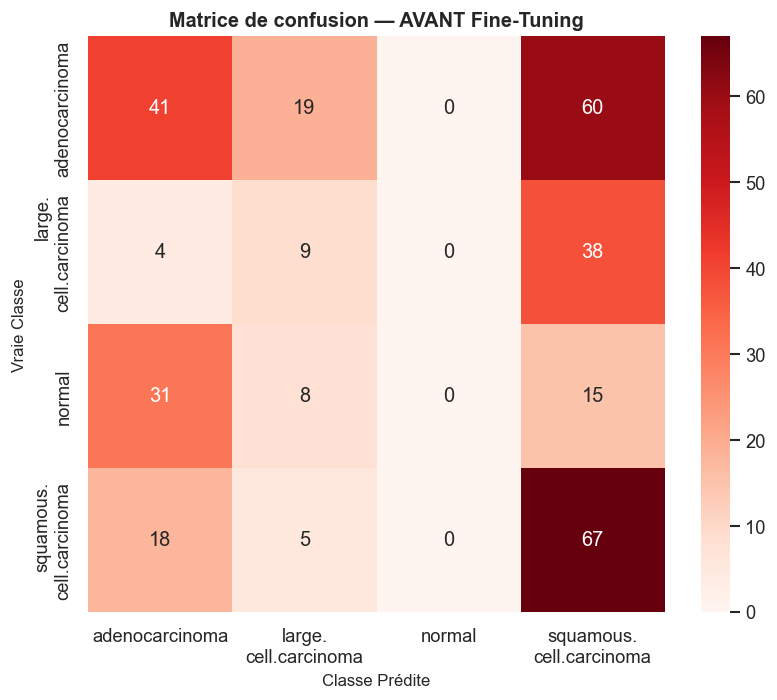

✅ Matrice sauvegardée : cm_before.png


In [6]:
# Évaluation sur le test set SANS fine-tuning
print("⏳ Évaluation en cours...")
metrics_before = evaluate_model(model_pretrained, test_loader)
print_metrics(metrics_before, "AVANT Fine-Tuning (modèle ImageNet brut)")

# Matrice de confusion
fig = plot_confusion_matrix(metrics_before['cm'],
                            title='Matrice de confusion — AVANT Fine-Tuning',
                            color='Reds')
plt.savefig('cm_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrice sauvegardée : cm_before.png")


# PARTIE 2 — Fine-Tuning sur le Dataset CT-Scan (10 époques)


In [7]:
# Recharger un modèle frais avec poids ImageNet
model_finetuned = torchvision.models.efficientnet_b0(
    weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
)
model_finetuned.classifier[-1] = nn.Linear(
    model_finetuned.classifier[-1].in_features, NUM_CLASSES
)
model_finetuned = model_finetuned.to(DEVICE)

# Loss pondérée 
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimiseur Adam
optimizer = torch.optim.Adam(model_finetuned.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler : réduit lr si val_loss ne s'améliore pas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5, verbose=True
)

NUM_EPOCHS    = 10
PATIENCE      = 3   # Early stopping

print("✅ Configuration fine-tuning :")
print(f"   Modèle     : EfficientNet-B0 (ImageNet → CT-scan)")
print(f"   Loss       : CrossEntropyLoss pondérée")
print(f"   Optimiseur : Adam (lr=1e-4, weight_decay=1e-4)")
print(f"   Époques    : {NUM_EPOCHS}")
print(f"   Early stop : patience={PATIENCE}")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [ ]:
# Boucle d'entraînement 
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

best_val_loss  = float('inf')
patience_count = 0
best_weights   = None

for epoch in range(NUM_EPOCHS):

    #  TRAIN    model_finetuned.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_finetuned(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    # ── VALIDATION ──
    model_finetuned.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs  = model_finetuned(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds    = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    # ── Scheduler & Early stopping ──
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_weights   = model_finetuned.state_dict().copy()
        patience_count = 0
        saved = '✅ meilleur modèle sauvegardé'
    else:
        patience_count += 1
        saved = f'⚠️  patience {patience_count}/{PATIENCE}'

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Époque {epoch+1:02d}/{NUM_EPOCHS} "
          f"| Train loss: {train_loss:.4f} acc: {train_acc:.3f} "
          f"| Val loss: {val_loss:.4f} acc: {val_acc:.3f} "
          f"| {saved}")

    if patience_count >= PATIENCE:
        print(f"\n🛑 Early stopping déclenché à l'époque {epoch+1}")
        break

# Recharger les meilleurs poids
model_finetuned.load_state_dict(best_weights)
torch.save(best_weights, 'efficientnet_finetuned.pth')
print(f"\n✅ Entraînement terminé ! Meilleur modèle sauvegardé : efficientnet_finetuned.pth")

In [ ]:
# Courbes d'entraînement
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'entraînement — EfficientNet-B0', fontsize=13, fontweight='bold')

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
ax1.set_title('Loss par époque', fontweight='bold')
ax1.set_xlabel('Époque'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
ax2.set_title('Accuracy par époque', fontweight='bold')
ax2.set_xlabel('Époque'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes sauvegardées : training_curves.png")

In [ ]:
# Évaluation APRÈS fine-tuning
print("⏳ Évaluation après fine-tuning...")
metrics_after = evaluate_model(model_finetuned, test_loader)
print_metrics(metrics_after, "APRÈS Fine-Tuning (modèle entraîné sur CT-scan)")

# Matrice de confusion
fig = plot_confusion_matrix(metrics_after['cm'],
                            title='Matrice de confusion — APRÈS Fine-Tuning',
                            color='Greens')
plt.savefig('cm_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrice sauvegardée : cm_after.png")


# PARTIE 3 — Comparaison Avant / Après Fine-Tuning

In [ ]:
# Tableau comparatif
metriques = ['accuracy', 'precision', 'recall', 'f1']
labels_m  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

before_vals = [metrics_before[m] for m in metriques]
after_vals  = [metrics_after[m]  for m in metriques]
gains       = [a - b for a, b in zip(after_vals, before_vals)]

print("\n" + "="*65)
print(f"  {'Métrique':<15} {'AVANT':>12} {'APRÈS':>12} {'GAIN':>12}")
print("="*65)
for lbl, bv, av, gv in zip(labels_m, before_vals, after_vals, gains):
    arrow = '📈' if gv > 0 else '📉'
    print(f"  {lbl:<15} {bv:>11.4f} {av:>11.4f} {arrow} {gv:>+.4f}")
print("="*65)

In [ ]:
# Graphique comparatif
x     = np.arange(len(labels_m))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, before_vals, width, label='AVANT fine-tuning',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, after_vals,  width, label='APRÈS fine-tuning',
               color='#2ecc71', alpha=0.85, edgecolor='white')

ax.set_title('Comparaison des métriques — Avant vs Après Fine-Tuning\nEfficientNet-B0',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_m, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#c0392b', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#27ae60', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : comparison_metrics.png")

In [ ]:
# Matrices de confusion côte à côte
short_names = ['adeno', 'large\ncell', 'normal', 'squamous']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrices de Confusion — Avant vs Après Fine-Tuning', fontsize=13, fontweight='bold')

sns.heatmap(metrics_before['cm'], annot=True, fmt='d', cmap='Reds',
            xticklabels=short_names, yticklabels=short_names, ax=ax1)
ax1.set_title('AVANT Fine-Tuning', fontweight='bold', color='#e74c3c')
ax1.set_xlabel('Prédit'); ax1.set_ylabel('Réel')

sns.heatmap(metrics_after['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=short_names, yticklabels=short_names, ax=ax2)
ax2.set_title('APRÈS Fine-Tuning', fontweight='bold', color='#27ae60')
ax2.set_xlabel('Prédit'); ax2.set_ylabel('Réel')

plt.tight_layout()
plt.savefig('cm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparaison matrices sauvegardée : cm_comparison.png")

In [ ]:
# Visualisation : images + prédictions APRÈS fine-tuning
model_finetuned.eval()
test_images, test_labels = next(iter(test_loader))
test_images_dev = test_images.to(DEVICE)

with torch.no_grad():
    outputs = model_finetuned(test_images_dev)
    probs   = torch.softmax(outputs, dim=1)
    preds   = torch.argmax(probs, dim=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Prédictions APRÈS Fine-Tuning (🟢 correct / 🔴 incorrect)',
             fontsize=12, fontweight='bold')

def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(t * std + mean, 0, 1)

for i, ax in enumerate(axes.flat):
    img_np     = denorm(test_images[i]).permute(1,2,0).numpy()
    true_label = CLASS_NAMES[test_labels[i].item()]
    pred_label = CLASS_NAMES[preds[i].item()]
    conf       = probs[i][preds[i].item()].item() * 100
    color      = '#27ae60' if pred_label == true_label else '#e74c3c'
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f"Vrai : {true_label[:14]}\nPréd : {pred_label[:14]} ({conf:.0f}%)",
                 color=color, fontsize=7.5)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions_after.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Visualisation sauvegardée : predictions_after.png")